#                       Global Currency Power Index (CCPI) 
###                                     A Multi-Dimensional Economic Analysis
######                                                             Author : Afreeda Shireen
######                                                      Data Analytics & Visualisation Data9005
######                                                                Submitted: 06 March 2026

In [29]:
# 1. Setup and data loading

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine learning / scaling
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv(
    # r"C:\Users\BASITH M A\Documents\Afreeda\SEM2_Module\DataAnalytics\World_dataset.csv"
    r"World_dataset.csv"
)

# Keep only relevant columns and rename
df = df.rename(columns={
    "Country Name": "Country",
    "Country Code": "Code",
    "Time": "Year",
    "GDP (current US$) [NY.GDP.MKTP.CD]": "GDP",
    "Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]": "Inflation",
    "Official exchange rate (LCU per US$, period average) [PA.NUS.FCRF]": "ExchangeRate",
    "Trade (% of GDP) [NE.TRD.GNFS.ZS]": "TradePercentGDP",
    "Total reserves (includes gold, current US$) [FI.RES.TOTL.CD]": "Reserves",
    "Current account balance (% of GDP) [BN.CAB.XOKA.GD.ZS]": "CurrentAccount"
})


df = df[[
    "Country", "Code", "Year", "GDP", "Inflation", "ExchangeRate",
    "TradePercentGDP", "Reserves", "CurrentAccount"
]]


#  safe conversion of Year
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Year"])
df["Year"] = df["Year"].astype(int)


df.head()

,Country,Code,Year,GDP,Inflation,ExchangeRate,TradePercentGDP,Reserves,CurrentAccount
0,Afghanistan,AFG,2000,3521418059.92345,..,47.3575747311828,..,..,..
1,Afghanistan,AFG,2001,2813571753.87253,..,47.500014516129,..,..,..
2,Afghanistan,AFG,2002,3825701438.99963,..,47.263,..,..,..
3,Afghanistan,AFG,2003,4520946818.54581,..,48.7627535833333,..,..,..
4,Afghanistan,AFG,2004,5224896718.67782,..,47.8453125,..,..,..


In [30]:
# 2. Cleaning and GDP share

# Replace ".." with proper missing values
df = df.replace("..", np.nan)

# Convert numeric columns
num_cols = ["GDP", "Inflation", "ExchangeRate",
            "TradePercentGDP", "Reserves", "CurrentAccount"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Compute global GDP and each country's share
df["Global_GDP"] = df.groupby("Year")["GDP"].transform("sum")
df["GDP_Share"] = df["GDP"] / df["Global_GDP"] * 100

df[["Country", "Year", "GDP", "GDP_Share"]].head()


,Country,Year,GDP,GDP_Share
0,Afghanistan,2000,3.521418e+09,0.001415
1,Afghanistan,2001,2.813572e+09,0.001134
2,Afghanistan,2002,3.825701e+09,0.001483
3,Afghanistan,2003,4.520947e+09,0.001553
4,Afghanistan,2004,5.224897e+09,0.001581


In [31]:
# 3. Filter to countries with enough data

country_counts = df.groupby("Country")[["GDP", "Inflation",
                                        "Reserves", "TradePercentGDP",
                                        "CurrentAccount"]].count()

# Require minimum observations per variable (approx > 60–70% completeness)
valid_countries = country_counts[
    (country_counts["GDP"] > 15) &
    (country_counts["Reserves"] > 15) &
    (country_counts["CurrentAccount"] > 15)
].index

df = df[df["Country"].isin(valid_countries)]

# Forward fill missing values within each country over time
df = df.sort_values(["Country", "Year"])
df[num_cols] = df.groupby("Country")[num_cols].ffill()

# Drop remaining rows with missing key variables
df = df.dropna(subset=num_cols)

df.head()


,Country,Code,Year,GDP,Inflation,ExchangeRate,TradePercentGDP,Reserves,CurrentAccount,Global_GDP,GDP_Share
25,Albania,ALB,2000,3.584570e+09,0.050018,143.709417,61.609261,6.463057e+08,-4.360355,2.488923e+14,0.001440
26,Albania,ALB,2001,4.059064e+09,3.107588,143.484833,64.247446,7.705812e+08,-5.355915,2.481121e+14,0.001636
27,Albania,ALB,2002,4.515003e+09,7.770526,140.154516,65.991465,8.664782e+08,-9.025907,2.580129e+14,0.001750
28,Albania,ALB,2003,5.801712e+09,0.484003,121.863250,64.823215,1.038294e+09,-7.011977,2.910995e+14,0.001993
29,Albania,ALB,2004,7.406646e+09,2.280019,102.780051,65.037938,1.387913e+09,-4.832490,3.305821e+14,0.002240


In [32]:
# 4. Construct CCPI index

features = ["GDP", "Reserves", "TradePercentGDP",
            "CurrentAccount", "Inflation"]

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

# Convert inflation: lower inflation = better score
df_scaled["Inflation"] = 1 - df_scaled["Inflation"]

# Composite index (weights)
df_scaled["CCPI"] = (
    df_scaled["GDP"] * 0.30 +
    df_scaled["Reserves"] * 0.25 +
    df_scaled["TradePercentGDP"] * 0.15 +
    df_scaled["CurrentAccount"] * 0.15 +
    df_scaled["Inflation"] * 0.15
)

df_scaled[["Country", "Year", "CCPI"]].head()


,Country,Year,CCPI
25,Albania,2000,0.187402
26,Albania,2001,0.187109
27,Albania,2002,0.185003
28,Albania,2003,0.187352
29,Albania,2004,0.187882


In [33]:
# 5. Correlation analysis

vars_corr = ["GDP", "Reserves", "TradePercentGDP",
             "CurrentAccount", "Inflation", "CCPI"]

corr_matrix = df_scaled[vars_corr].corr()
corr_matrix


,GDP,Reserves,TradePercentGDP,CurrentAccount,Inflation,CCPI
GDP,1.000000,0.620633,-0.174464,0.021348,0.044387,0.716293
Reserves,0.620633,1.000000,-0.072738,0.069423,0.045938,0.749997
TradePercentGDP,-0.174464,-0.072738,1.000000,0.137500,0.115762,0.422945
CurrentAccount,0.021348,0.069423,0.137500,1.000000,0.047484,0.270017
Inflation,0.044387,0.045938,0.115762,0.047484,1.000000,0.256215
CCPI,0.716293,0.749997,0.422945,0.270017,0.256215,1.000000


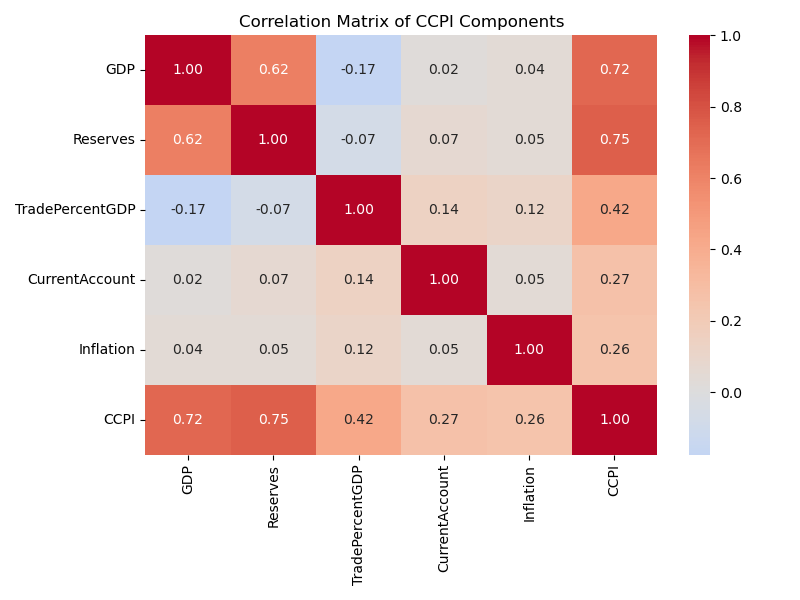

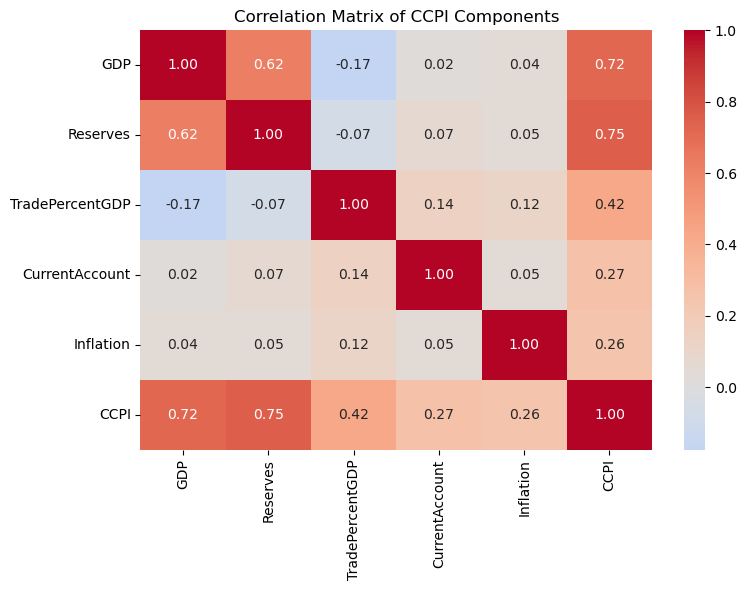

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlation Matrix of CCPI Components")
plt.tight_layout()
from IPython.display import Image, display
display(Image(url='https://afreedashireen.github.io/global-currency-power-index/visuals/correlation_heatmap.png'))

In [ ]:
# 6. Top 5 CCPI trajectories

top5_countries = (
    df_scaled.groupby("Country")["CCPI"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

df_top5 = df_scaled[df_scaled["Country"].isin(top5_countries)]

fig = px.line(
    df_top5,
    x="Year",
    y="CCPI",
    color="Country",
    title="Structural Currency Power Trajectories (Top 5 Economies)"
)
from IPython.display import IFrame, display
display(IFrame(src='https://afreedashireen.github.io/global-currency-power-index/visuals/top5_ccpi_trajectories.html', width=800, height=600))

In [ ]:
# 7. Share of global CCPI

df_share = df_scaled.copy()
df_share["Global_Total"] = df_share.groupby("Year")["CCPI"].transform("sum")
df_share["CCPI_Share"] = df_share["CCPI"] / df_share["Global_Total"]

df_share_top5 = df_share[df_share["Country"].isin(top5_countries)]

fig = px.area(
    df_share_top5,
    x="Year",
    y="CCPI_Share",
    color="Country",
    title="Share of Global Currency Power (Top 5 Economies)"
)
fig.update_layout(yaxis_title="Share of Global CCPI")
from IPython.display import IFrame, display
display(IFrame(src='https://afreedashireen.github.io/global-currency-power-index/visuals/global_ccpi_share_top5.html', width=800, height=600))

In [ ]:
# 8. Structural landscape

import plotly.express as px

fig = px.scatter(
    df_scaled,
    x="GDP",
    y="Inflation",
    size="Reserves",
    color="CCPI",
    animation_frame="Year",
    hover_name="Country",
    size_max=60,
    title="Evolution of Structural Currency Power"
)

fig.update_layout(
    xaxis_title="GDP (Scaled)",
    yaxis_title="Inflation (Scaled)"
)

from IPython.display import IFrame, display
display(IFrame(src='https://afreedashireen.github.io/global-currency-power-index/visuals/structural_currency_power_evolution.html', width=800, height=600))

In [ ]:
# 9. Clustering structural regimes

latest_year = df_scaled["Year"].max()
df_cluster = df_scaled[df_scaled["Year"] == latest_year].copy()

cluster_features = ["GDP", "Inflation", "ExchangeRate",
                    "TradePercentGDP", "Reserves", "CurrentAccount"]

X = df_cluster[cluster_features]

# Standardize
scaler_std = StandardScaler()
X_scaled = scaler_std.fit_transform(X)

# K-means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster["Cluster"] = kmeans.fit_predict(X_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_cluster["PC1"] = X_pca[:, 0]
df_cluster["PC2"] = X_pca[:, 1]

fig = px.scatter(
    df_cluster,
    x="PC1",
    y="PC2",
    color="Cluster",
    hover_name="Country",
    title="Structural Currency Power Regimes (PCA + K-Means)"
)
fig.update_layout(
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)
from IPython.display import IFrame, display
display(IFrame(src='https://afreedashireen.github.io/global-currency-power-index/visuals/currency_power_regimes_pca_kmeans.html', width=800, height=600))

# PCA loadings for interpretation
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=cluster_features
)
print(loadings)

                      PC1       PC2
GDP              0.689351  0.042535
Inflation        0.052482 -0.479466
ExchangeRate    -0.090856  0.353060
TradePercentGDP -0.194068 -0.563156
Reserves         0.684403 -0.045789
CurrentAccount   0.087843 -0.569571


In [ ]:
# 10. Structural shift analysis

def structural_bar(year1, year2):
    """Compute change in CCPI between two years for each country."""
    df_shock = df_scaled[df_scaled["Year"].isin([year1, year2])].copy()

    shock_pivot = df_shock.pivot(
        index="Country",
        columns="Year",
        values="CCPI"
    ).dropna()

    shock_pivot["Change"] = shock_pivot[year2] - shock_pivot[year1]
    shock_pivot = shock_pivot.reset_index()
    shock_pivot = shock_pivot.sort_values("Change", ascending=False)

    return shock_pivot

year1 = 2008
year2 = 2020
data_shift = structural_bar(year1, year2)

top_n = 15
plot_data = data_shift.head(top_n)

fig = px.bar(
    plot_data,
    x="Country",
    y="Change",
    color="Change",
    color_continuous_scale="RdBu",
    title=f"Structural Currency Power Shift: {year1} vs {year2}"
)
fig.update_layout(
    xaxis_title="Country",
    yaxis_title="Change in CCPI",
    xaxis_tickangle=-45
)
from IPython.display import IFrame, display
display(IFrame(src='https://afreedashireen.github.io/global-currency-power-index/visuals/currency_power_shift_2008_2020.html', width=800, height=600))

In [ ]:
import plotly.express as px

df_ranked = df_scaled.copy()

df_ranked["Rank"] = (
    df_ranked.groupby("Year")["CCPI"]
    .rank(ascending=False, method="first")
)

df_top15 = df_ranked[df_ranked["Rank"] <= 15]

fig = px.bar(
    df_top15,
    x="CCPI",
    y="Country",
    color="Country",
    animation_frame="Year",
    orientation="h",
    range_x=[0, df_top15["CCPI"].max()],
    title="Global Currency Power Rankings (CCPI)"
)

fig.update_layout(yaxis={'categoryorder':'total ascending'})
from IPython.display import IFrame, display
display(IFrame(src='https://afreedashireen.github.io/global-currency-power-index/visuals/global_currency_power_rankings.html', width=800, height=600))

In [ ]:
df_scaled["Country"].unique()[:10]

import plotly.express as px

fig = px.choropleth(
    df_scaled,
    locations="Country",
    locationmode="country names",
    color="CCPI",
    hover_name="Country",
    animation_frame="Year",
    color_continuous_scale="Plasma",
    title="Global Currency Power Distribution (CCPI)"
)

fig.update_layout(coloraxis_colorbar_title="CCPI Score")

from IPython.display import IFrame, display
display(IFrame(src='https://afreedashireen.github.io/global-currency-power-index/visuals/global_currency_power_distribution.html', width=800, height=600))

In [ ]:
# -----------------------------
# 8. Advanced: Dynamic CCPI Repositioning (Any Years)
# -----------------------------
def structural_scatter_dynamic(year1, year2):
    """
    Creates a scatter plot comparing CCPI between ANY two user-selected years.
    Points above the 45-degree line gained power; below lost power.
    """
    # Filter data for the two years
    df_shock = df_scaled[df_scaled["Year"].isin([year1, year2])].copy()
    
    # Pivot to get both years side-by-side
    shock_pivot = df_shock.pivot(
        index="Country",
        columns="Year",
        values="CCPI"
    ).dropna()
    
    # Reset index and calculate change
    shock_pivot = shock_pivot.reset_index()
    shock_pivot["Change"] = shock_pivot[year2] - shock_pivot[year1]
    
    return shock_pivot

# DYNAMIC: Show available years and let user pick
available_years = sorted(df_scaled["Year"].unique())
print(f"Available years: {available_years[:5]}...{available_years[-5:]}")

# Default to interesting crisis periods, but CHANGE THESE AS NEEDED
year1 = 2008  # GFC
year2 = 2020  # COVID
print(f"\nUsing years: {year1} vs {year2}")
print("Change year1/year2 above to compare different periods!")

data = structural_scatter_dynamic(year1, year2)

# Create the advanced scatter plot
import plotly.express as px

fig = px.scatter(
    data,
    x=year1,                    
    y=year2,                    
    color="Change",             
    color_continuous_scale="RdBu",  
    hover_name="Country",       
    size_max=15,                
    title=f"Structural Currency Power Repositioning: {year1} vs {year2}"
)

# Dynamic 45-degree reference line
min_val = min(data[year1].min(), data[year2].min())
max_val = max(data[year1].max(), data[year2].max())

fig.add_shape(
    type="line",
    x0=min_val, y0=min_val,
    x1=max_val, y1=max_val,
    line=dict(dash="dash", color="black", width=2)
)

# Dynamic labels
fig.update_layout(
    xaxis_title=f"CCPI ({year1}) - Scaled structural power",
    yaxis_title=f"CCPI ({year2}) - Scaled structural power",
    coloraxis_colorbar_title="CCPI Change",
    width=800,
    height=600,
    showlegend=False
)

from IPython.display import IFrame, display
display(IFrame(src='https://afreedashireen.github.io/global-currency-power-index/visuals/currency_power_repositioning_2008_2020.html', width=800, height=600))

# Show top 5 gainers/losers for the selected period
print("\n" + "="*60)
print(f"TOP 5 GAINERS ({year1}→{year2}):")
gainers = data.nlargest(5, "Change")[["Country", "Change"]].round(3)
print(gainers.to_string(index=False))

print(f"\nTOP 5 LOSERS ({year1}→{year2}):")
losers = data.nsmallest(5, "Change")[["Country", "Change"]].round(3)
print(losers.to_string(index=False))

Available years: [2000, 2001, 2002, 2003, 2004]...[2020, 2021, 2022, 2023, 2024]

Using years: 2008 vs 2020
Change year1/year2 above to compare different periods!



TOP 5 GAINERS (2008→2020):
      Country  Change
        China   0.187
United States   0.086
  Switzerland   0.069
      Ireland   0.036
        India   0.033

TOP 5 LOSERS (2008→2020):
    Country  Change
Timor-Leste  -0.133
      Sudan  -0.055
      Libya  -0.038
    Algeria  -0.028
     Panama  -0.025


## Dynamic Interpretation


- `2000, 2024`: Long-run structural shifts
- `2008, 2009`: GFC immediate impact  
- `2019, 2020`: COVID shock
- `2020, 2024`: Post-COVID recovery

**The 45° line rule works for ANY period:**
- Above = gained relative power
- Below = lost relative power  
- Color intensity = size of shift
- Table shows exact top gainers/losers
